'''
```
=================================================

Data Analisis ini bertujuan untuk menganalisa datasets yang berisikan data ecommerce Indonesia dari tahun 2023-2025 dan tujuan utamanya adalah untuk mengurangi penggagalan pesanan/order cancellation karena tingginya order cancellation bisa menurunkan pendapatan perusahaan secara signifikan
=================================================
```
'''

Sumber Dataset:
https://www.kaggle.com/datasets/bakitacos/indonesia-e-commerce-sales-and-shipping-20232025

Problem Statement dan Dataset Description:

Problem Statement:
Mengidentifikasi faktor-faktor utama penyebab tingginya tingkat pembatalan pesanan pada platform e-commerce ini yang saat ini berada di angka 13,57% (periode Desember 2023 - November 2025), dengan target menurunkan angka tersebut menjadi 12,5% atau lebih rendah dalam kurun waktu 1 tahun ke depan, melalui analisis pola pembatalan berdasarkan alasan, metode pembayaran, opsi pengiriman, guna meningkatkan profitabilitas dan konversi pesanan secara keseluruhan.

Datasets description: 
Dataset ini berisi transaksi e-commerce Indonesia selama 24 bulan (Des 2023 – Nov 2025), termasuk informasi di tingkat pesanan mengenai jumlah produk, biaya pengiriman, diskon, metode pembayaran, dan tujuan pengiriman

Link Tableau Public:
https://public.tableau.com/views/Book1_17726417772740/Sheet3?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

Data Exploration:

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.set_palette('Set2')


In [16]:
df = pd.read_csv('all_months_clean.csv', sep=";")

df.head(5)

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


Berikut di atas merupakan gambaran 5 data pertama datasets ecommerce

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

Dari hasil analisa summary datasets bisa diliat terdapat 18 kolom dan 208484 baris. Terutama di bagian kolom alasan pembatalan sangat banyak sekali yang null tetapi itu wajar karena banyak pengguna/user yang tidak memberi tahu alasan mereka cancel order. Dan untuk isi dataset tersebut terdiri dari sekira 9 kolom numeric (int64) yakni yang memiliki angka berbobot/berjumlah yang dapat dihitung (cth: total_qty, Total Diskon ) serta memiliki sekira 10 kolom berkonstuk categorical/string (object) yaitu data kualitatif serta kategorik (cth: product_categories,Provinsi )

Data Cleaning:

In [9]:
# Pertama ubah kolom Waktu Pesanan dibuat jadi Date time

df['Waktu Pesanan Dibuat'] = pd.to_datetime(df['Waktu Pesanan Dibuat'])

In [11]:
# Cek Null Value
df.isnull().sum()

order_id                                  0
total_qty                                 0
total_weight_gr                           0
total_returned_qty                        0
Total Diskon                              0
product_categories                        0
num_product_categories                    0
Status Pesanan                            0
Alasan Pembatalan                     18018
Opsi Pengiriman                           0
Metode Pembayaran                         0
Kota/Kabupaten                            0
Provinsi                                  0
Ongkos Kirim Dibayar oleh Pembeli         0
Estimasi Potongan Biaya Pengiriman        0
Total Pembayaran                          0
Perkiraan Ongkos Kirim                    0
Waktu Pesanan Dibuat                   1980
source_file                               0
dtype: int64

Dari hasil perhitungan null. Bisa dilihat ada 18018 null value di Kolom Alasan Pembatalan. Null value akan diganti dengan "Alasan Tidak Diketahui"

In [ ]:
# Handling Null Value Kolom Alasan Pembatalan

alasan_baru = []

# disini saya mau mengganti value Null yang di kolom Alasan Pembatalan

for status, alasan in zip(df['Status Pesanan'], df['Alasan Pembatalan']):
    if status == "Selesai":
        alasan_baru.append("Tidak Dibatalkan")
    elif status == "Batal" and pd.isna(alasan):
        alasan_baru.append("Tidak Diketahui")
    else:
        alasan_baru.append(alasan)

df['Alasan Pembatalan'] = alasan_baru

In [15]:
# Tahap terakhir data cleaning
# Drop kolom source_file
df = df.drop(columns=['source_file'])

In [ ]:
# Simpan file hasil cleaning ke yang baru
df.to_csv('all_months_clean_2.csv', index=False)

In [ ]:
dfc = pd.read_csv('all_months_clean_2.csv')

dfc.head(5)

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,Tidak Dibatalkan,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15:00
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,Tidak Dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47:00
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,Tidak Dibatalkan,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25:00
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,Tidak Dibatalkan,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41:00
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12:00


Penjabaran 1: Menghitung Frekuensi alasan pembatalan

In [6]:
frekuensi_alasan = dfc['Alasan Pembatalan'].value_counts()

tabel_alasan_pembatalan = frekuensi_alasan[frekuensi_alasan.index != "Tidak Dibatalkan"]
top_10_alasan = tabel_alasan_pembatalan.head(10)

# Menghitung jumlah nilai "Batal" di kolom "Status Pesanan" menggunakan filtering
dfc_batal = dfc[dfc["Status Pesanan"] == "Batal"]
jumlah_batal = len(dfc_batal)

# Yang di ambil top 10 teratas aja biar grafiknya tidak terlalu padat
print(top_10_alasan)
print(f"Total pesanan dibatalkan: {len(dfc_batal)}")
# Menghitung jumlah nilai "Batal" di kolom "Status Pesanan" menggunakan filtering

# Persentase batal
persentase_batal = (jumlah_batal/len(dfc)) * 100
print(f"Persentase pesanan yang dibatalkan: {persentase_batal:.2f}%")

Alasan Pembatalan
Dibatalkan oleh Pembeli. Alasan: Lainnya/ berubah pikiran                                        662
Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan yang Ada                                           558
Dibatalkan secara otomatis oleh sistem. Alasan: Pesanan belum dibayar                            447
Dibatalkan oleh Pembeli. Alasan: Need to change delivery address                                 306
Dibatalkan secara otomatis oleh sistem. Alasan: Pengiriman gagal                                 255
Dibatalkan secara otomatis oleh sistem. Alasan: Penjual gagal mengirimkan pesanan tepat waktu    113
Dibatalkan oleh Pembeli. Alasan: Perlu mengubah pesanan                                          113
Dibatalkan oleh Pembeli. Alasan: Perlu mengubah alamat pengiriman                                 79
Dibatalkan secara otomatis oleh sistem. Alasan: Penjual tidak mengatur pengiriman tepat waktu     63
Dibatalkan oleh Pembeli. Alasan: Lainnya                                 

C:\Users\mrich\AppData\Local\Temp\ipykernel_11940\2086642561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


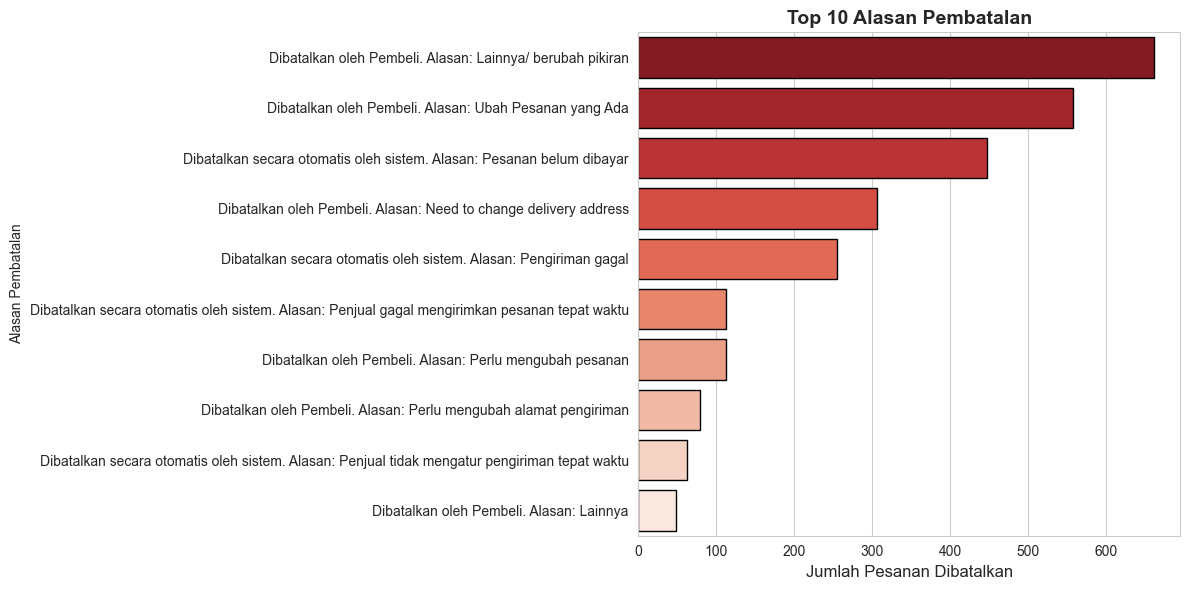

In [7]:
# Visualisasi Bar Plot Horizontal - Untuk Alasan pembatalan

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=top_10_alasan.values,
    y=top_10_alasan.index,
    palette='Reds_r',
    edgecolor='black',
    ax=ax)

ax.set_title('Top 10 Alasan Pembatalan', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Pesanan Dibatalkan', fontsize=12)

plt.tight_layout()
plt.show()


Berdasarkan hasil analisa jumlah pembatalan per alasan yang ada. Bisa di tarik kesimpulannya bahwa paling banyak pembeli membatalkan pesanan ya karena memang pembeli berubah pikiran saja 

Penjabaran 2: Persentase pembatalan per metode pembayaran

In [8]:
# Untuk kelompokan data berdasarkan metode pembayaran dan hitung jumlah baris di setiap kelompok dengan .size() method
total_per_metode = dfc.groupby('Metode Pembayaran').size()

batal_per_metode = dfc_batal.groupby('Metode Pembayaran').size()

persentase_batal_metode_pembayaran = (batal_per_metode.reindex(total_per_metode.index, fill_value=0) / total_per_metode) * 100


persentase_batal_metode_pembayaran = persentase_batal_metode_pembayaran.sort_values(ascending=False)

print("Persentase Pembatalan per Metode Pembayaran: ")
for metode, persen in persentase_batal_metode_pembayaran.items():
    jumlah_batal = batal_per_metode.reindex(total_per_metode.index, fill_value=0)[metode]
    jumlah_total = total_per_metode[metode]
    print(f"Metode {metode}: {persen:.2f}% ({int(jumlah_batal)} dari {jumlah_total})")

Persentase Pembatalan per Metode Pembayaran: 
Metode Mitra Shopee: 100.00% (1 dari 1)
Metode Indomaret/i.Saku: 48.84% (21 dari 43)
Metode Alfamart/Alfamidi/Dan+Dan: 47.22% (17 dari 36)
Metode BCA OneKlik: 33.33% (1 dari 3)
Metode Online Payment: 18.55% (588 dari 3170)
Metode SPayLater: 14.88% (221 dari 1485)
Metode COD (Bayar di Tempat): 13.38% (1544 dari 11538)
Metode SeaBank Bayar Instan: 13.34% (85 dari 637)
Metode Kartu Kredit/Debit: 13.06% (29 dari 222)
Metode Saldo ShopeePay: 8.72% (322 dari 3692)
Metode Pembayaran dibebaskan: 5.56% (1 dari 18)
Metode Cicilan Kartu Kredit: 0.00% (0 dari 3)


C:\Users\mrich\AppData\Local\Temp\ipykernel_11940\3147928071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


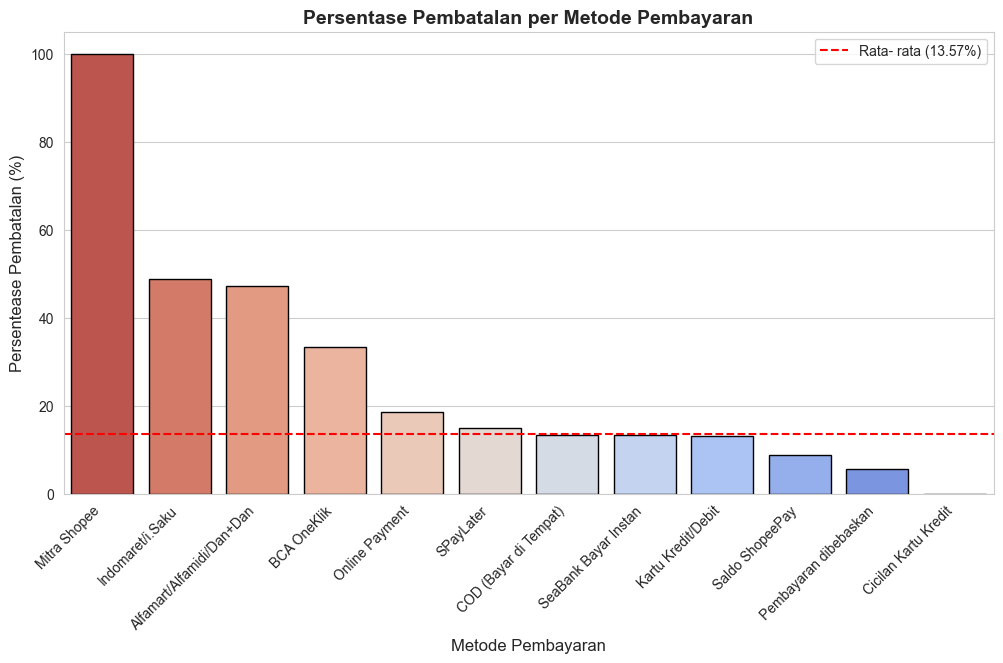

In [9]:
# Visualisasi Bar Plot Vertikal - Pembatalan per Metode Pembayaran

df_metode = pd.DataFrame({
    'Metode Pembayaran': persentase_batal_metode_pembayaran.index,
    "Persentase Pembatalan": persentase_batal_metode_pembayaran.values
})

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_metode,
    x="Metode Pembayaran",
    y="Persentase Pembatalan",
    palette="coolwarm_r",
    edgecolor="black",
    ax=ax
)

ax.axhline(y=13.57, color='red', linestyle='--', linewidth=1.5, label='Rata- rata (13.57%)')

ax.set_title('Persentase Pembatalan per Metode Pembayaran', fontsize=14, fontweight='bold')
ax.set_xlabel('Metode Pembayaran', fontsize=12)
ax.set_ylabel('Persentease Pembatalan (%)', fontsize=12)
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.show()

Berikut bar horizontal di atas berdasarkan perhitungan persentase pembatalan per metode pembayaran dengan rata2 yang di representasikan dengan titik putus-putus merah yaitu 13.57%. Tetapi ada satu persentase cancellation dari metode pembayaran mitra shopee yang 100 % ini di karenakan ada satu pembeli menggunakan pembayaran metode Mitra Shopee tapi kemudian di cancel dan tidak ada pembeli lain yang menggunakan metode tersebut. Tapi ada 3 yang perlu diperhatikan Indomaret/Saku, Alfamrt/Alfamidi/Dan+Dan dan BCA One Klik karena angka persentasenya lumayan jauh di atas rata2

Penjabaran 3: Persentase pembatalan per opsi pengiriman

In [18]:
total_per_kirim = dfc.groupby('Opsi Pengiriman').size()

batal_per_kirim = dfc_batal.groupby('Opsi Pengiriman').size()

persen_batal_kirim = (batal_per_kirim.reindex(total_per_kirim.index, fill_value=0)/ total_per_kirim) * 100

persen_batal_kirim = persen_batal_kirim.sort_values(ascending=False).head(10)
print("Top 10 Opsi Pengiriman dengan Pembatalan Tertinggi: ")

for opsi, persen in persen_batal_kirim.items():
    total = total_per_kirim[opsi]
    batal = batal_per_kirim.reindex(total_per_kirim.index, fill_value=0)[opsi]

    print(f"Opsi {opsi}: {persen:.2f}% ({int(batal)} dari {total})")

Top 10 Opsi Pengiriman dengan Pembatalan Tertinggi: 
Opsi Reguler (Cashless): 100.00% (190 dari 190)
Opsi Hemat Kargo: 100.00% (460 dari 460)
Opsi GoSend Instant Prioritas: 100.00% (1 dari 1)
Opsi Kargo: 100.00% (48 dari 48)
Opsi Same Day: 100.00% (17 dari 17)
Opsi Instant (Versi Lama): 100.00% (42 dari 42)
Opsi Instant: 100.00% (5 dari 5)
Opsi Next Day: 100.00% (3 dari 3)
Opsi J&T Economy: 60.00% (3 dari 5)
Opsi GrabExpress Instant: 50.00% (3 dari 6)


C:\Users\mrich\AppData\Local\Temp\ipykernel_4600\2598863697.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


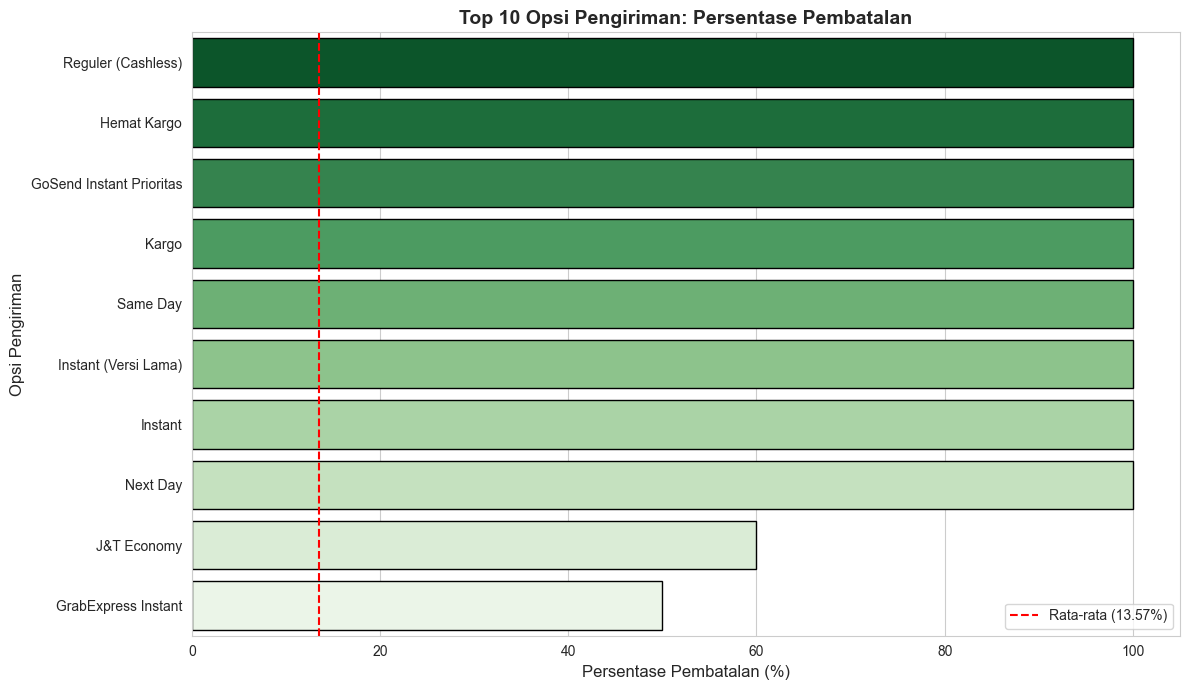

In [24]:
df_kirim = pd.DataFrame({
    'Opsi Pengiriman': persen_batal_kirim.index,
    'Persentase Pembatalan': persen_batal_kirim.values
})

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_kirim,
    x='Persentase Pembatalan',
    y='Opsi Pengiriman',
    palette='Greens_r',
    edgecolor='black',
    ax=ax
)

ax.axvline(x=13.57, color='red', linestyle='--', linewidth=1.5, label='Rata-rata (13.57%)')
ax.set_title('Top 10 Opsi Pengiriman: Persentase Pembatalan', fontsize=14, fontweight='bold')
ax.set_xlabel('Persentase Pembatalan (%)', fontsize=12)
ax.set_ylabel('Opsi Pengiriman', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

Berdasarkan hasil filter untuk top 10 Opsi Pengiriman Persentase pembatalan 100% dan volume kecil kemungkinan opsi itu sudah dihentikan. Tapi untuk Hemat Kargo(460 pesanan semua batal) dan Reguler Cashless(190 pesanan, 100% batal juga) perlu dperhatikan karena angka pembatalannya 100% dan jumlahnya cukup signifikan. Selain itu J&T Economy dan GrabExpress Instant juga perlu mendapat perhatian karena persentase pembatalannya juga di atas rata2 50 sampai 60%, sehingga mungkin perlu dievaluasi terkait kualitas layanan atau estimasi ongkirnya

Penjabaran 4: Trend Pembatalan per Bulan

In [27]:
# Hapus baris yang Waktu Pesanan Dibuat-nya NAN(Null)
# Masukin ke DataFrame baru biar tidak menimpa yang lama
dfc_waktu = dfc.dropna(subset=['Waktu Pesanan Dibuat']).copy()
# Convert ke datetime dulu karena dfc dibaca dari CSV
dfc_waktu['Waktu Pesanan Dibuat'] = pd.to_datetime(dfc_waktu['Waktu Pesanan Dibuat'])
# Buat kolom baru berformat periode bulanan
dfc_waktu['Bulan_Tahun'] = dfc_waktu['Waktu Pesanan Dibuat'].dt.to_period('M')

# Hitung total pesanan per bulan
total_per_bulan = dfc_waktu.groupby('Bulan_Tahun').size()

# Hitung total pesanan batal per bulan
batal_per_bulan = dfc_waktu[dfc_waktu['Status Pesanan'] == 'Batal'].groupby('Bulan_Tahun').size()

# Hitung persentase pembatalan per bulan
persen_batal_bulan = (batal_per_bulan.reindex(total_per_bulan.index, fill_value=0) / total_per_bulan) * 100

print("Persentase Pembatalan per Bulan: ")
for bulan, persen in persen_batal_bulan.items():
    print(f"Bulan {bulan}: {persen:.2f}")

Persentase Pembatalan per Bulan: 
Bulan 2023-12: 20.72
Bulan 2024-01: 14.85
Bulan 2024-02: 15.94
Bulan 2024-03: 14.13
Bulan 2024-04: 18.09
Bulan 2024-05: 15.32
Bulan 2024-06: 12.77
Bulan 2024-07: 12.28
Bulan 2024-08: 15.16
Bulan 2024-09: 13.89
Bulan 2024-10: 13.06
Bulan 2024-11: 13.98
Bulan 2025-01: 12.61
Bulan 2025-02: 12.75
Bulan 2025-03: 17.83
Bulan 2025-04: 17.72
Bulan 2025-05: 20.76
Bulan 2025-06: 15.45
Bulan 2025-08: 9.24
Bulan 2025-09: 10.17
Bulan 2025-10: 9.38
Bulan 2025-11: 8.93


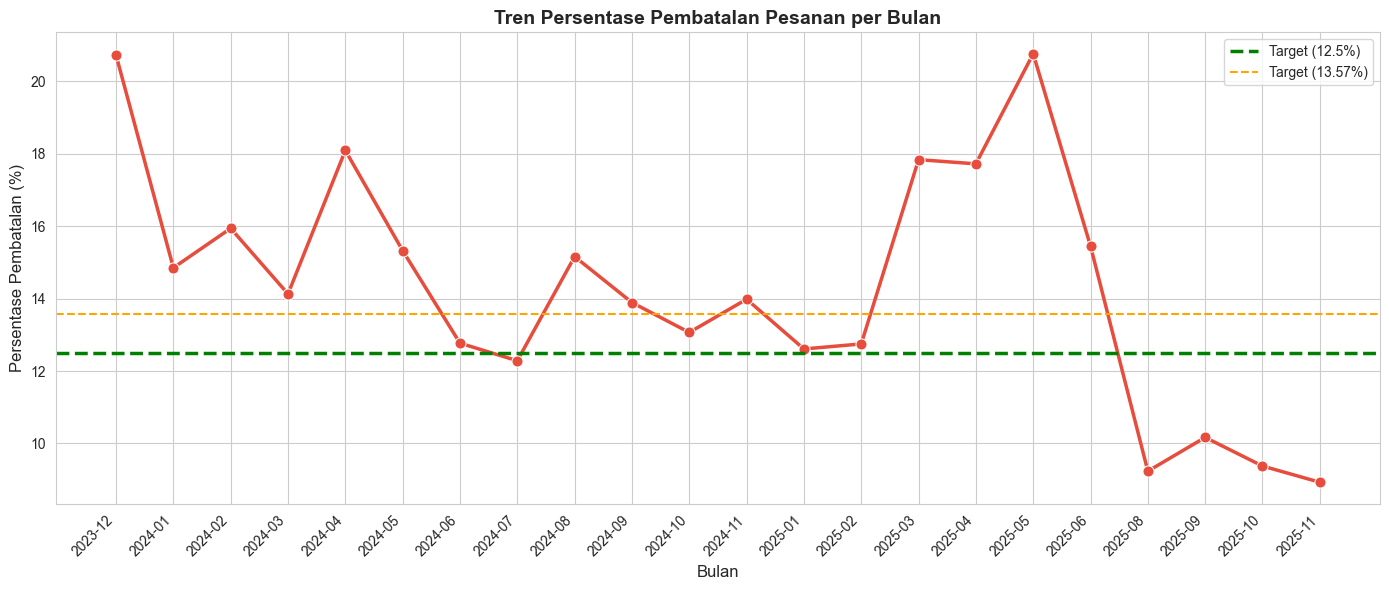

In [28]:
# Visualisasi Line Plot Tren Pembatalan Per Bulan

df_tren = pd.DataFrame({
    'Bulan': persen_batal_bulan.index.astype(str),
    'Persentase Pembatalan':
    persen_batal_bulan.values
})

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=df_tren,
    x='Bulan',
    y='Persentase Pembatalan',
    marker='o',
    linewidth=2.5,
    color='#e74c3c',
    markersize=8,
    ax=ax
)

ax.axhline(y=12.5, color='green', linestyle='--', linewidth=2.5, label='Target (12.5%)') 
ax.axhline(y=13.57, color='orange', linestyle='--', linewidth=1.5, label='Target (13.57%)') 

ax.set_title('Tren Persentase Pembatalan Pesanan per Bulan', fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Persentase Pembatalan (%)', fontsize=12)
ax.legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan tren persentase pembatalan pesanan per bulan maka bisa disimpulkan:

1. Persentase pembatalan cenderung stabil di kisaran 13-14% sepanjang 24 bulan, tanpa lonjakan signifikan. Ini menunjukkan masalah bersifat struktural, bukan musiman.
2. Waspada Lonjakan Musiman: Terdapat dua titik puncak (Garis Naik Drastis) dengan tingkat pembatalan telat tinggi (sekitar 20,7%), yakni di Desember 2023 dan Mei 2025. Ini kemungkinan efek dari kewalahan pesanan di masa promo/hari raya.
3. Kuartal 1 Labil: Angka pesanan batal selalu naik-turun secara acak di setiap periode Januari - April. Sistem manajemen pesanan perlu dievaluasi khusus untuk empat bulan pertama ini pada tahun berikutnya.

Penjabaran 5: Statistik Deskriptif

In [29]:
# Karena fokus utama menurunkan rate pesanan yang batal maka akan lihat pola ongkirnya
ongkir_batal = dfc_batal['Perkiraan Ongkos Kirim']

# Central Tendency

mean_ongkir = ongkir_batal.mean()
median_ongkir = ongkir_batal.median()
mode_ongkir = ongkir_batal.mode()[0]
std_ongkir = ongkir_batal.std()

skew_ongkir = ongkir_batal.skew()

print("Mean Ongkir:", mean_ongkir)
print("Median Ongkir:", median_ongkir)
print("Mode Ongkir:", mode_ongkir)
print("Standard Deviation Ongkir:", std_ongkir)
print("Skewness Ongkir:", skew_ongkir)

Mean Ongkir: 25585.357597173144
Median Ongkir: 16000.0
Mode Ongkir: 8000
Standard Deviation Ongkir: 37247.76206171194
Skewness Ongkir: 9.386378232924162


Pembatalan paling banyak terjadi di kisaran ongkir rendah (mode: Rp8.000), bukan ongkir mahal. Artinya tingginya ongkir bukan satu-satunya penyebab pembatalan — faktor lain seperti "berubah pikiran" kemungkinan lebih dominan, yang sejalan dengan temuan di penjabaran 1.

Penjabaran 6: Statistik Inferensial

In [22]:
from scipy.stats import mannwhitneyu

# Pakai metode inferensial Mann Whitney U Test karena data ongkir sangat right skewed sehingga asumsi normalitas buat t-test tidak terpenuhi
# Pisahkan ongkir pesanan batal vs selesai
ongkir_batal = dfc[dfc['Status Pesanan'] == 'Batal']['Perkiraan Ongkos Kirim']
ongkir_selesai = dfc[dfc['Status Pesanan'] == 'Selesai']['Perkiraan Ongkos Kirim']

# H0: Tidak ada perbedaan ongkir antara pesanan batal dan selesai
# H1: Ada perbedaan ongkir antara pesanan batal dan selesai
alpha = 0.05

stat, p_value = mannwhitneyu(ongkir_batal, ongkir_selesai, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.2f}")
print(f"P-value: {p_value}")
print()

if p_value < alpha:
    print(f"P-value ({p_value:.2e}) < alpha ({alpha})")
    print("Tolak H0: Ada perbedaan signifikan ongkir antara pesanan batal dan selesai.")
else:
    print(f"P-value ({p_value:.2e}) >= alpha ({alpha})")
    print("Gagal tolak H0: Tidak ada perbedaan signifikan ongkir antara pesanan batal dan selesai.")

Mann-Whitney U Statistic: 30060549.00
P-value: 2.845570398989274e-63

P-value (2.85e-63) < alpha (0.05)
Tolak H0: Ada perbedaan signifikan ongkir antara pesanan batal dan selesai.


Berdasarkan hasil Mann-Whitney U Test (p-value = 2.85e-63):

Ada perbedaan signifikan secara statistik antara ongkir pesanan yang dibatalkan dan yang selesai. Meskipun secara statistik ada perbedaan ongkir antara pesanan batal dan selesai, perbedaan tersebut tidak cukup besar untuk dijadikan faktor utama. Ongkir bukan satu-satunya — bahkan bukan faktor terkuat — penyebab pembatalan. Rekomendasi intervensi lebih tepat diarahkan ke pengalaman user sebelum checkout (misal: fitur reminder, konfirmasi pesanan) untuk menekan pembatalan akibat "berubah pikiran".

Kesimpulan:

Dari analisis terhadap datasets transaksi e-commerce periode Desember 2023 – November 2025, ditemukan tingkat pembatalan pesanan sebesar 13,57%. Untuk mencapai target penurunan ke 12,5% dalam 1 tahun, berikut temuan utamanya:

- Alasan Pembatalan (Penjabaran 1): Faktor dominan pembatalan adalah "pembeli berubah pikiran", bukan karena masalah teknis, harga, atau ongkir. Ini menunjukkan bahwa intervensi harus difokuskan pada tahap pre-checkout dan post-order experience.

- Metode Pembayaran (Penjabaran 2): Secara umum, persentase pembatalan per metode pembayaran berada di sekitar rata-rata 13,57%. Anomali 100% pada Mitra Shopee disebabkan volume sangat kecil (1 transaksi), sehingga bukan indikator masalah sistemik.

- Opsi Pengiriman (Penjabaran 3): Beberapa opsi pengiriman menunjukkan tingkat pembatalan 100%, namun didorong oleh volume transaksi yang sangat kecil. Opsi pengiriman bukan faktor pembeda utama pembatalan.

- Tren Bulanan (Penjabaran 4): Persentase pembatalan cenderung stabil di kisaran 13-14% sepanjang 24 bulan, tanpa lonjakan signifikan. Ini menunjukkan masalah bersifat struktural, bukan musiman.

- Statistik Deskriptif (Penjabaran 5): Ongkir pesanan batal memiliki mode Rp8.000 (rendah), mean Rp25.585, dan distribusi sangat right-skewed (9.39). Pembatalan justru paling banyak terjadi di ongkir murah, bukan mahal.

- Statistik Inferensial (Penjabaran 6): Mann-Whitney U Test menunjukkan perbedaan signifikan ongkir antara pesanan batal vs selesai (p-value = 2.85e-63)

Rekomendasi untuk mencapai target 12,5%:

1. Tambahkan fitur konfirmasi ulang sebelum pesanan diproses untuk mengurangi pembatalan akibat "berubah pikiran"
2. Implementasikan reminder/notifikasi pasca-order agar pembeli tidak lupa atau berubah pikiran
3. Evaluasi opsi pengiriman dengan volume kecil tapi pembatalan tinggi — pertimbangkan untuk menghapus atau menggabungkannya
4. Berikan insentif (diskon/cashback) bagi pembeli yang menyelesaikan pesanan tanpa membatalkan
